
## NIO and cost






## Inputs



(2, 'i_h2i_rate')

(3, 'i_pci_rate')

(5, 'i_ngi_rate')

(6, 'i_o2_volfract')

(8, 'i_h2_temp')

(9, 'i_hbtemp')

(10, 'i_wind_rt')


## Outputs


* desired output requirements 


(27, 'o_tgt')

(29, 'o_hmt')

(39, 'o_prod_rt')

(40, 'o_fta')

(28, 'o_coke_rt')



In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime
## !pip install pandas
## !pip install scikit-learn
## !pip install matplotlib
## !pip install seaborn
## !pip install mlxtend
## ! pip install skl2onnx



In [2]:


import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)

import os, json, time, uuid


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score





In [3]:


import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt




/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/onnx_ops.py:159: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  tys = obj.typeStr or ''
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/automation.py:154: UserWarning: OpSchema.FormalParameter.isHomogeneous is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.is_homogeneous instead.
  if getattr(obj, 'isHomogeneous', False):
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/jinja2/environment.py:485: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  return getattr(obj, attribute)


In [4]:

import PDFshapingUtils as PDF_tk


In [5]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()


In [6]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.16.2025.csv')


In [7]:

## Ty suggested fix where 0 needs to be 300

PDFshapingOBJ.CFD_raw_data["i_h2_temp"] = PDFshapingOBJ.CFD_raw_data["i_h2_temp"].replace(0, 300)


In [8]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HB...,0,0,0,120,21,300,300,1200,...,20.0,44.9,122.0,264.0,687.0,31.6,26.7,63.5,4050.0,1800.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.6,50.9,123.0,266.0,690.0,27.7,23.5,60.8,4080.0,1850.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.2,124.0,268.0,690.0,27.7,23.2,60.6,4090.0,1850.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.4,124.0,268.0,695.0,27.7,23.2,60.7,4110.0,1850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,4995,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,18.7,40.3,353.0,763.0,2190.0,34.0,20.5,56.7,11700.0,2380.0
4995,4996,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,18.7,40.7,353.0,763.0,2190.0,33.8,20.4,56.8,11700.0,2310.0
4996,4997,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,19.2,37.5,353.0,763.0,2230.0,33.6,20.4,57.1,11700.0,2380.0
4997,4998,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,17.6,39.8,355.0,768.0,2220.0,34.0,20.0,55.7,11800.0,2310.0


In [9]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_H2COratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_H2COratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

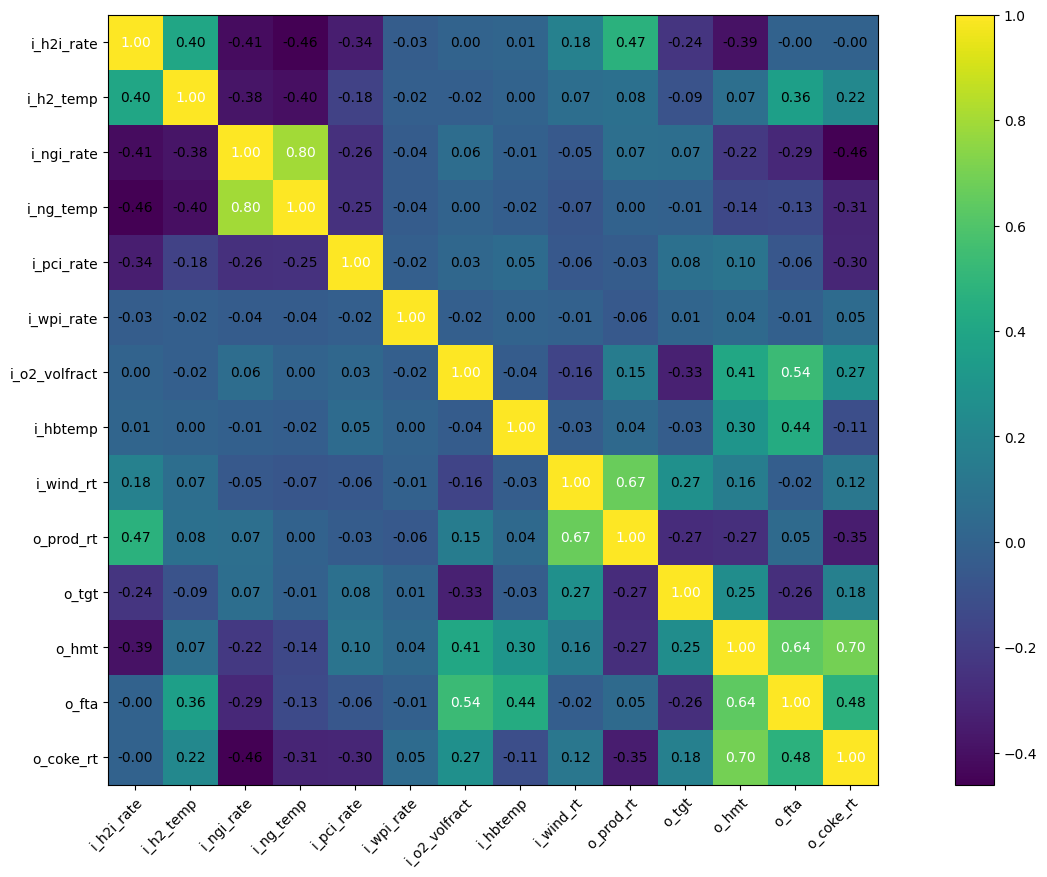

In [10]:


PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','o_prod_rt', 'o_tgt', 'o_hmt','o_fta', 'o_coke_rt']



PDFshapingOBJ.print_correlation_coefficients()


In [11]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-7_SGI-0_SGT-0_SGC_0 '
  0 ... 63.5 4050.0 1800.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC_0 '
  0 ... 60.6 4060.0 1850.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  0 ... 60.8 4080.0 1850.0]
 ...
 [4997
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1600_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 57.1 11700.0 2380.0]
 [4998
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-3_SGI-0_SGT-0_SGC_0 '
  30 ... 55.7 11800.0 2310.0]
 [4999
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 56.2 11800.0 2310.0]]
(4999, 41)


In [12]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [  2, 3, 5, 6, 8, 9, 10   ] , 
                   outputs= [ 27, 29, 39, 40, 28 ]   
)


## inputs = [ 2, 3, 5, 6, 8, 9, 10  ]          ## the full 7



7
5


In [13]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4999, 7)
(4999, 5)


In [14]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [15]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [16]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [17]:

'''


from sklearn.decomposition import PCA

# Instantiate PCA to reduce to 4 components
pca = PCA(n_components=4)

# Fit on training data and transform both train and test
X_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)
X_test_pca  = pca.transform(PDFshapingOBJ.X_test)

# Replace the original inputs with PCA-reduced versions
PDFshapingOBJ.X_train = X_train_pca
PDFshapingOBJ.X_test  = X_test_pca


'''


'\n\n\nfrom sklearn.decomposition import PCA\n\n# Instantiate PCA to reduce to 4 components\npca = PCA(n_components=4)\n\n# Fit on training data and transform both train and test\nX_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)\nX_test_pca  = pca.transform(PDFshapingOBJ.X_test)\n\n# Replace the original inputs with PCA-reduced versions\nPDFshapingOBJ.X_train = X_train_pca\nPDFshapingOBJ.X_test  = X_test_pca\n\n\n'

In [18]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [19]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [20]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [21]:


PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## Model Forward ( 7x4 )


In [22]:

n_inputs  = 7     ## 7
n_outputs = 5




#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO_Forward(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations,  device='cuda'):
        super().__init__()
        self.device = device
        
        ## self.x_means      = x_means
        ## self.x_deviations = x_deviations
        ## self.y_means      = y_means
        ## self.y_deviations = y_deviations
        
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)
        
        
        
        ## F1
        self.f1_linear1 = nn.Linear(n_inputs, n_outputs)       
        
        ## F2
        self.f2_linear1 = nn.Linear(n_inputs, 10)
        self.f2_act1    = nn.Tanh()   ## nn.Sigmoid()    ## Tanh()    nn.ReLU()                 
        self.f2_linear2 = nn.Linear(10, n_outputs)       
        self.f2_dropout = nn.Dropout(0.25)
        
        # Move model to device
        self.to(self.device)
        
        
    ## perform inference
    def forward(self, x):
        x = x.to(self.device)
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        ##   y_descaled = torch.clamp(  y_descaled, min=0.0  )
        
        return y_descaled, y_scaled
    




In [23]:

n_inputs  = 7    ## 7
n_outputs = 5





    
class ResidualNet_Forward(nn.Module):
    def __init__(self, x_means, x_deviations, y_means, y_deviations, dropout_rate=0.1, device='cuda'):
        
        super().__init__()
        self.device = device
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)

     
        self.fc1  = nn.Linear(n_inputs, 64)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(64, 64)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(64, n_outputs)

        # If input_dim ≠ 64, project for residual addition
        self.input_proj = nn.Linear(n_inputs, 64) if n_inputs != 64 else nn.Identity()
        
        # Move model to device
        self.to(self.device)
        

    def forward(self, x):
        x  = x.to(self.device)
        x  = (x - self.x_means) / self.x_deviations
        x0 = self.input_proj(x)
        x1 = self.dropout1(self.act1(self.fc1(x)))
        x2 = self.dropout2(self.act2(self.fc2(x1)))
        x_res = x2 + x0
        y_scaled = self.fc3(x_res)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

    


In [24]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## model_Forward     = F1plusF2_SIO_Forward(

model_Forward     =     F1plusF2_SIO_Forward(
                         PDFshapingOBJ.x_means, 
                         PDFshapingOBJ.x_deviations, 
                         PDFshapingOBJ.y_means, 
                         PDFshapingOBJ.y_deviations,
                         device=device  # pass device into the model
    
)

optimizer = optim.Adam(model_Forward.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()



In [25]:

model_Forward.train()

for epoch in range(1000):
    for xb, yb in PDFshapingOBJ.train_dl:
        
        xb = xb.to(model_Forward.device)
        yb = yb.to(model_Forward.device)
        
        optimizer.zero_grad()
        pred_descaled, pred_scaled = model_Forward(xb)
        
        loss = loss_fn(pred_scaled, yb)
        loss.backward()
        optimizer.step()
    if epoch % 100 == 0:
        print(epoch, ".....", loss.item() ) 
    



0 ..... 0.2817403972148895
100 ..... 0.14291271567344666
200 ..... 0.2697090804576874
300 ..... 0.19449561834335327
400 ..... 0.34919941425323486
500 ..... 0.15309962630271912
600 ..... 0.24743616580963135
700 ..... 0.3492104709148407
800 ..... 0.1751018762588501
900 ..... 0.137363001704216


In [26]:

print("=== SANITY CHECK: SCALING ===")
print("y_means:", PDFshapingOBJ.y_means)
print("y_deviations:", PDFshapingOBJ.y_deviations)

print("===============================================")

print("x_means:", PDFshapingOBJ.x_means)
print("x_deviations:", PDFshapingOBJ.x_deviations)


=== SANITY CHECK: SCALING ===
y_means: tensor([[  98.0358, 1296.4496, 8434.0068, 2306.5518,  417.0708]])
y_deviations: tensor([[  50.9676,  526.2429, 1516.6299,  212.4174,   50.1486]])
x_means: tensor([[  12.4731,   18.9097,   41.4219,   25.5916,  416.1290, 1439.2258,
          198.4571]])
x_deviations: tensor([[ 15.2670,  45.5479,  46.5844,   3.3170, 272.5061, 156.7860,  26.4889]])


In [27]:

print(PDFshapingOBJ.y_means -  PDFshapingOBJ.y_deviations)
print(PDFshapingOBJ.y_means +  PDFshapingOBJ.y_deviations)


tensor([[  47.0682,  770.2067, 6917.3770, 2094.1343,  366.9221]])
tensor([[ 149.0034, 1822.6925, 9950.6367, 2518.9692,  467.2194]])


In [28]:

print(PDFshapingOBJ.x_means -  PDFshapingOBJ.x_deviations)
print(PDFshapingOBJ.x_means +  PDFshapingOBJ.x_deviations)


tensor([[  -2.7938,  -26.6382,   -5.1625,   22.2747,  143.6229, 1282.4398,
          171.9682]])
tensor([[  27.7401,   64.4577,   88.0062,   28.9086,  688.6351, 1596.0118,
          224.9460]])


In [29]:

import numpy as np
from numpy.linalg import norm

# --- distance function ---
def euclid(a, b):
    return norm(a - b)



## Now add Costs


In [30]:

def regularize_z(z, strength=1e-3):
    
    return strength * torch.sum(z**2)


In [31]:

clamp_min = torch.tensor([[   0,   0,   0,    21,   300,   1200, 150 ]])     ## from Ty
clamp_max = torch.tensor([[ 300, 300, 300,    90,  3000,   1500, 220 ]])



get_x_from_z = lambda z: clamp_min + (clamp_max - clamp_min) * torch.sigmoid(z)


In [32]:

def wrapped_model(x):
    y_descaled, _ = model_Forward(x)
    return y_descaled  


In [33]:

price_real = np.array([4.0, 1.0, 0.5, 0.0, 0.0, 0.0, 0.0])

price_real = torch.tensor(price_real, dtype=torch.float32)


model_Forward.eval()


for p in model_Forward.parameters():
    p.requires_grad = False



In [34]:

lambda_cost = 0.1        ## 0.01    ## 0.001   ## this gave 86% percent of cases improvement
## lambda_cost = 0.0

dist_method_A = []
dist_method_B = []
cost_diffs    = [] 
cost_diff     = 0

percent_diffs = []
percent_diff  = 0 

learning_rate = 0.01        ## 0.001      ## 1e-5


In [35]:



for i in range(  1, PDFshapingOBJ.X_test.shape[0]  ):
    
    target_y  = torch.tensor( PDFshapingOBJ.y_test[i]   )    ## what you want y ?
    x_real    = torch.tensor( PDFshapingOBJ.X_test[i]   )    ## real x
    
    target_y  = (target_y  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations
    
    ## x_starting_point = torch.tensor(   PDFshapingOBJ.X_test[0]   )    ## starting point
    ## x_temp = x_starting_point.clone().detach().requires_grad_(True)
    ## z_init = torch.rand((1,7))*0.4 + 0.3
    
    z_init = torch.rand((1,7))*0.2 + 0.3
    z = torch.nn.Parameter(torch.logit(z_init))    ## this requires grad 
          

    ## x_temp = torch.randn_like(x_starting_point).requires_grad_(True)

    optimizer = torch.optim.Adam([z], lr=learning_rate)
    

    for j in range(1000):
        
        optimizer.zero_grad()
        
        x_temp = get_x_from_z(  z  )
        
        _, current_y = model_Forward(x_temp)
        
        
        loss_z_reg = regularize_z(z, strength=1e-3)
        loss_main  = torch.mean((current_y - target_y)**2)
        ## loss_cost  = lambda_cost * torch.dot(price_real, x_temp)
        loss_cost  = lambda_cost * (x_temp @ price_real)
        loss       = loss_main + loss_cost + loss_z_reg
        
        loss.backward()
        optimizer.step()
        
        
    
        #######################
        
     
        x_temp_pred_np   = x_temp.detach().numpy()
        ## cost_pred        = np.dot(   price_real, x_temp_pred_np)
        cost_pred        = torch.dot(price_real, x_temp.squeeze()).item()
        
        x_real_np        = x_real.detach().numpy() 
        cost_real        = np.dot(price_real, x_real_np)
       
        if j % 200 == 0:           ## 20
            print(f"iteration {j} cost: {cost_pred}...H2, PCI, NGI:", x_temp_pred_np[:,:3] )
            print("real cost       :", cost_real)
            print( "total loss", loss      )
            print( "loss_main",  loss_main )
            print( "loss_cost",  loss_cost )
        
   
        cost_diff = cost_pred - cost_real
        if cost_real > 0:                         ## handle nans
            percent_diff = cost_diff / cost_real
            percent_diffs.append(percent_diff)
        
          
    cost_diffs.append(    cost_diff  )
      

    the_cols = "    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    
    
    print("...")
    print("...")
    print("...")
    print( the_cols )
    print( "pred" )
    print( x_temp_pred_np )
    print( "real" )
    print( x_real_np )
    print("...")
    print( "y pred" )
    print( wrapped_model(torch.from_numpy(x_temp_pred_np))   )
    print( "y real" )
    print( wrapped_model(torch.from_numpy(x_real_np))   )
    
    dist_method_A.append( euclid(x_temp_pred_np, x_real_np) )
    dist_method_B.append( euclid(
                    wrapped_model(torch.from_numpy(x_temp_pred_np)).detach().numpy() , 
                    wrapped_model(torch.from_numpy(x_real_np)).detach().numpy()
    ))
    
    print(i)
    print('********************************')




iteration 0 cost: 678.9719848632812...H2, PCI, NGI: [[131.04266 109.42951  90.74365]]
real cost       : 30.0
total loss tensor([90.1253], grad_fn=<AddBackward0>)
loss_main tensor(22.2259, grad_fn=<MeanBackward0>)
loss_cost tensor([67.8972], grad_fn=<MulBackward0>)
iteration 200 cost: 216.1746368408203...H2, PCI, NGI: [[41.88495  33.169807 30.930086]]
real cost       : 30.0
total loss tensor([23.3765], grad_fn=<AddBackward0>)
loss_main tensor(1.7349, grad_fn=<MeanBackward0>)
loss_cost tensor([21.6175], grad_fn=<MulBackward0>)
iteration 400 cost: 97.21815490722656...H2, PCI, NGI: [[18.494661 15.075745 16.32753 ]]
real cost       : 30.0
total loss tensor([10.0091], grad_fn=<AddBackward0>)
loss_main tensor(0.2487, grad_fn=<MeanBackward0>)
loss_cost tensor([9.7218], grad_fn=<MulBackward0>)
iteration 600 cost: 56.582130432128906...H2, PCI, NGI: [[10.607205  8.867061 10.572494]]
real cost       : 30.0
total loss tensor([5.8298], grad_fn=<AddBackward0>)
loss_main tensor(0.1223, grad_fn=<MeanBa

iteration 200 cost: 214.14678955078125...H2, PCI, NGI: [[36.27887  47.187943 43.686737]]
real cost       : 70.0
total loss tensor([25.7110], grad_fn=<AddBackward0>)
loss_main tensor(4.2769, grad_fn=<MeanBackward0>)
loss_cost tensor([21.4147], grad_fn=<MulBackward0>)
iteration 400 cost: 97.45986938476562...H2, PCI, NGI: [[16.455307 20.340021 22.597244]]
real cost       : 70.0
total loss tensor([11.3364], grad_fn=<AddBackward0>)
loss_main tensor(1.5548, grad_fn=<MeanBackward0>)
loss_cost tensor([9.7460], grad_fn=<MulBackward0>)
iteration 600 cost: 57.1708984375...H2, PCI, NGI: [[ 9.578535 11.464679 14.784154]]
real cost       : 70.0
total loss tensor([6.8453], grad_fn=<AddBackward0>)
loss_main tensor(1.0765, grad_fn=<MeanBackward0>)
loss_cost tensor([5.7171], grad_fn=<MulBackward0>)
iteration 800 cost: 36.89109802246094...H2, PCI, NGI: [[ 6.064075  7.461653 10.34629 ]]
real cost       : 70.0
total loss tensor([4.3956], grad_fn=<AddBackward0>)
loss_main tensor(0.6374, grad_fn=<MeanBackwar

iteration 200 cost: 211.01116943359375...H2, PCI, NGI: [[36.453197 49.67972  31.037317]]
real cost       : 40.0
total loss tensor([23.1132], grad_fn=<AddBackward0>)
loss_main tensor(1.9920, grad_fn=<MeanBackward0>)
loss_cost tensor([21.1011], grad_fn=<MulBackward0>)
iteration 400 cost: 96.14517211914062...H2, PCI, NGI: [[16.605278 21.401463 16.645199]]
real cost       : 40.0
total loss tensor([10.0523], grad_fn=<AddBackward0>)
loss_main tensor(0.4046, grad_fn=<MeanBackward0>)
loss_cost tensor([9.6145], grad_fn=<MulBackward0>)
iteration 600 cost: 56.108360290527344...H2, PCI, NGI: [[ 9.648988 12.107451 10.809916]]
real cost       : 40.0
total loss tensor([5.8321], grad_fn=<AddBackward0>)
loss_main tensor(0.1788, grad_fn=<MeanBackward0>)
loss_cost tensor([5.6108], grad_fn=<MulBackward0>)
iteration 800 cost: 36.89092254638672...H2, PCI, NGI: [[6.3127666 7.825961  7.6277924]]
real cost       : 40.0
total loss tensor([3.8219], grad_fn=<AddBackward0>)
loss_main tensor(0.0811, grad_fn=<MeanBa

iteration 400 cost: 121.53936767578125...H2, PCI, NGI: [[22.163733 20.16681  25.435251]]
real cost       : 20.5
total loss tensor([12.3207], grad_fn=<AddBackward0>)
loss_main tensor(0.1244, grad_fn=<MeanBackward0>)
loss_cost tensor([12.1539], grad_fn=<MulBackward0>)
iteration 600 cost: 70.72386932373047...H2, PCI, NGI: [[12.673421 11.718954 16.622461]]
real cost       : 20.5
total loss tensor([7.2563], grad_fn=<AddBackward0>)
loss_main tensor(0.1279, grad_fn=<MeanBackward0>)
loss_cost tensor([7.0724], grad_fn=<MulBackward0>)
iteration 800 cost: 47.41304016113281...H2, PCI, NGI: [[ 8.417986   7.7835355 11.915126 ]]
real cost       : 20.5
total loss tensor([5.0801], grad_fn=<AddBackward0>)
loss_main tensor(0.2722, grad_fn=<MeanBackward0>)
loss_cost tensor([4.7413], grad_fn=<MulBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   6.1215186    5.586865     9.090024    22.793112   382.35913
  1214.8607     170.91959  

iteration 200 cost: 270.2488708496094...H2, PCI, NGI: [[51.27266  44.40539  41.505695]]
real cost       : 160.0
total loss tensor([28.1355], grad_fn=<AddBackward0>)
loss_main tensor(1.0909, grad_fn=<MeanBackward0>)
loss_cost tensor([27.0249], grad_fn=<MulBackward0>)
iteration 400 cost: 124.9609146118164...H2, PCI, NGI: [[23.09932  20.446823 24.23363 ]]
real cost       : 160.0
total loss tensor([12.8746], grad_fn=<AddBackward0>)
loss_main tensor(0.3438, grad_fn=<MeanBackward0>)
loss_cost tensor([12.4961], grad_fn=<MulBackward0>)
iteration 600 cost: 73.23377227783203...H2, PCI, NGI: [[13.227226 12.19366  16.262424]]
real cost       : 160.0
total loss tensor([7.9105], grad_fn=<AddBackward0>)
loss_main tensor(0.5329, grad_fn=<MeanBackward0>)
loss_cost tensor([7.3234], grad_fn=<MulBackward0>)
iteration 800 cost: 48.94679641723633...H2, PCI, NGI: [[ 8.760604   7.9651113 11.878537 ]]
real cost       : 160.0
total loss tensor([5.7913], grad_fn=<AddBackward0>)
loss_main tensor(0.8273, grad_fn=<

...

iteration 200 cost: 233.24472045898438...H2, PCI, NGI: [[41.3269   48.36681  39.140625]]
real cost       : 30.0
total loss tensor([27.2963], grad_fn=<AddBackward0>)
loss_main tensor(3.9479, grad_fn=<MeanBackward0>)
loss_cost tensor([23.3245], grad_fn=<MulBackward0>)
iteration 400 cost: 106.60725402832031...H2, PCI, NGI: [[18.791222 20.948896 20.98694 ]]
real cost       : 30.0
total loss tensor([12.2170], grad_fn=<AddBackward0>)
loss_main tensor(1.5119, grad_fn=<MeanBackward0>)
loss_cost tensor([10.6607], grad_fn=<MulBackward0>)
iteration 600 cost: 60.486873626708984...H2, PCI, NGI: [[10.583917 11.541085 13.220245]]
real cost       : 30.0
total loss tensor([6.8357], grad_fn=<AddBackward0>)
loss_main tensor(0.7321, grad_fn=<MeanBackward0>)
loss_cost tensor([6.0487], grad_fn=<MulBackward0>)
iteration 800 cost: 39.198333740234375...H2, PCI, NGI: [[6.7345543 7.61316   9.293919 ]]
real cost       : 30.0
total loss tensor([4.3913], grad_fn=<AddBackward0>)
loss_main tensor(0.4072, grad_fn=<Mea

iteration 600 cost: 56.578269958496094...H2, PCI, NGI: [[ 8.913979 10.683328 20.478062]]
real cost       : 140.0
total loss tensor([7.8306], grad_fn=<AddBackward0>)
loss_main tensor(2.1121, grad_fn=<MeanBackward0>)
loss_cost tensor([5.6578], grad_fn=<MulBackward0>)
iteration 800 cost: 42.17740249633789...H2, PCI, NGI: [[ 6.5762944  6.8214817 18.101488 ]]
real cost       : 140.0
total loss tensor([6.9154], grad_fn=<AddBackward0>)
loss_main tensor(2.6248, grad_fn=<MeanBackward0>)
loss_cost tensor([4.2177], grad_fn=<MulBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   4.9891353    4.7316475   14.716782    22.78999    382.75854
  1216.8934     213.51321  ]]
real
[   0.   80.  120.   24.  300. 1480.  230.]
...
y pred
tensor([[ 122.7522, 1389.9889, 7667.9678, 2192.1389,  463.8703]])
y real
tensor([[  119.0939,   824.4818, 10855.5000,  2168.2712,   310.3898]])
981
********************************
iteration 0 cost: 73

iteration 400 cost: 75.94256591796875...H2, PCI, NGI: [[12.923256 12.805589 22.887915]]
real cost       : 120.0
total loss tensor([7.8332], grad_fn=<AddBackward0>)
loss_main tensor(0.1992, grad_fn=<MeanBackward0>)
loss_cost tensor([7.5943], grad_fn=<MulBackward0>)
iteration 600 cost: 46.308406829833984...H2, PCI, NGI: [[ 7.8342633  7.5720677 14.798566 ]]
real cost       : 120.0
total loss tensor([5.0799], grad_fn=<AddBackward0>)
loss_main tensor(0.3957, grad_fn=<MeanBackward0>)
loss_cost tensor([4.6308], grad_fn=<MulBackward0>)
iteration 800 cost: 31.58181381225586...H2, PCI, NGI: [[ 5.348311   5.0519533 10.273231 ]]
real cost       : 120.0
total loss tensor([3.7499], grad_fn=<AddBackward0>)
loss_main tensor(0.5241, grad_fn=<MeanBackward0>)
loss_cost tensor([3.1582], grad_fn=<MulBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   3.8725915    3.6068735    7.61303     23.514101   460.20868
  1215.1182     193.500

iteration 200 cost: 248.66448974609375...H2, PCI, NGI: [[44.399204 43.461754 55.21185 ]]
real cost       : 125.0
total loss tensor([25.6231], grad_fn=<AddBackward0>)
loss_main tensor(0.7390, grad_fn=<MeanBackward0>)
loss_cost tensor([24.8664], grad_fn=<MulBackward0>)
iteration 400 cost: 120.7978515625...H2, PCI, NGI: [[20.865328 20.811493 33.05009 ]]
real cost       : 125.0
total loss tensor([12.8075], grad_fn=<AddBackward0>)
loss_main tensor(0.6910, grad_fn=<MeanBackward0>)
loss_cost tensor([12.0798], grad_fn=<MulBackward0>)
iteration 600 cost: 77.21281433105469...H2, PCI, NGI: [[12.791877 13.704463 24.681684]]
real cost       : 125.0
total loss tensor([8.8924], grad_fn=<AddBackward0>)
loss_main tensor(1.1106, grad_fn=<MeanBackward0>)
loss_cost tensor([7.7213], grad_fn=<MulBackward0>)
iteration 800 cost: 53.805931091308594...H2, PCI, NGI: [[ 8.745268  8.998203 19.653316]]
real cost       : 125.0
total loss tensor([7.1698], grad_fn=<AddBackward0>)
loss_main tensor(1.7127, grad_fn=<Mean

iteration 600 cost: 50.02185821533203...H2, PCI, NGI: [[ 7.884239 10.895739 15.178327]]
real cost       : 20.5
total loss tensor([5.9194], grad_fn=<AddBackward0>)
loss_main tensor(0.8717, grad_fn=<MeanBackward0>)
loss_cost tensor([5.0022], grad_fn=<MulBackward0>)
iteration 800 cost: 32.900718688964844...H2, PCI, NGI: [[ 5.145411  7.109775 10.418596]]
real cost       : 20.5
total loss tensor([3.9480], grad_fn=<AddBackward0>)
loss_main tensor(0.5970, grad_fn=<MeanBackward0>)
loss_cost tensor([3.2901], grad_fn=<MulBackward0>)
...
...
...
    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt
pred
[[   3.6521933    5.0682073    7.6368346   23.699589  1035.935
  1465.692      217.2198   ]]
real
[   0.    0.   41.   24.  300. 1600.  230.]
...
y pred
tensor([[ 124.9752, 2024.8400, 7695.6719, 2512.2563,  478.0072]])
y real
tensor([[ 136.6090, 2065.3281, 8393.3955, 2477.5610,  466.2340]])
996
********************************
iteration 0 cost: 737.2301635742

In [36]:

avg_A = np.mean(dist_method_A)


print("Average Euclidean Distance of Xs:")
print("Method A:", avg_A)


Average Euclidean Distance of Xs:
Method A: 444.62924


In [37]:

avg_B = np.mean(dist_method_B)


print("Average Euclidean Distance of Ys:")
print("Method A:", avg_B)


Average Euclidean Distance of Ys:
Method A: 1410.0358


In [38]:

print("average cost diff:",    np.mean(cost_diffs))
print("average percent diff:", np.mean(percent_diffs)*100, "%")


average cost diff: -58.86733722591305
average percent diff: 130.87511292373725 %


In [39]:

better = np.sum(np.array(cost_diffs) < 0)
total  = len(cost_diffs)


print("solver cheaper in:", better/total*100, "% of cases")


solver cheaper in: 92.1921921921922 % of cases


In [40]:

print(total)
print(better)


999
921
